# Classicmodels E-commerce Sales: Exploratory Data Analysis (EDA)

**Author:** Shekh Shahed Jiban  
**GitHub:** [GitHub Profile](https://github.com/shekhshahedjiban)  
**LinkedIn:** [LinkedIn Profile](https://linkedin.com/in/shekhshahedjiban)  
**Email:** shekhshahedjiban@gmail.com  

---

## Project overview
This project performs an in depth **Exploratory Data Analysis (EDA)** on the relational database **ClassicModels** using **SQL** and **Python**. The objective is to extract transactional data, evaluate sales performance, analyze revenue distributions across product lines, observe monthly order trends, and uncover geographic purchasing patterns to support data driven business decision making.

---

## Tools & libraries Used
* **SQL (MySQL Server & mysql-connector-python):** Database querying, table joining, and data extraction
* **Python (Core Programming):** Data processing, transformations, and feature engineering
* **Pandas & NumPy:** Data cleaning, aggregation, and structural manipulation
* **Matplotlib & Seaborn:** Custom statistical visualization and insight formatting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings

In [2]:
# setting visual styles and warning filters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 1. Establishing database connection & schema exploration
We establish a connection to the local MySQL instance using Python's `mysql.connector` to query the `classicmodels` database.

In [3]:
# Establishing connection to local MySQL server
try:
    conn = mysql.connector.connect(
        host="localhost",
        user="root",
        password="73737",
        database="classicmodels"
    )
    print(" Successfully connected to classicmodels database!")
except Exception as e:
    print(f" Connection failed: {e}")

 Successfully connected to classicmodels database!


In [4]:
# Retrieving all available relational tables in the schema
tables_df = pd.read_sql("SHOW TABLES;", conn)
print("\nAvailable tables in database:")
display(tables_df)


Available tables in database:


,Tables_in_classicmodels
0,customers
1,employees
2,offices
3,orderdetails
4,orders
5,payments
6,productlines
7,products


## 2. Initial data extraction & overview
Joining relational tables (`orders`, `orderdetails`, `products`, `customers`) via SQL to create a flat, consolidated DataFrame containing relevant dimensions and transaction metrics.

In [5]:
# Master SQL Query joining multiple relational entities
master_query = """
SELECT 
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country,
    c.city,
    p.productName,
    p.productLine,
    od.quantityOrdered,
    od.priceEach,
    (od.quantityOrdered * od.priceEach) AS totalAmount
FROM orders o
JOIN orderdetails od ON o.orderNumber = od.orderNumber
JOIN products p ON od.productCode = p.productCode
JOIN customers c ON o.customerNumber = c.customerNumber;
"""

In [6]:
# Executing SQL query and loading into Pandas DataFrame
df = pd.read_sql(master_query, conn)

print("Dataset Head:")
display(df.head())

Dataset Head:


,orderNumber,orderDate,status,customerName,country,city,productName,productLine,quantityOrdered,priceEach,totalAmount
0,10100,2003-01-06,Shipped,Online Diecast Creations Co.,USA,Nashua,1917 Grand Touring Sedan,Vintage Cars,30,136.00,4080.00
1,10100,2003-01-06,Shipped,Online Diecast Creations Co.,USA,Nashua,1911 Ford Town Car,Vintage Cars,50,55.09,2754.50
2,10100,2003-01-06,Shipped,Online Diecast Creations Co.,USA,Nashua,1932 Alfa Romeo 8C2300 Spider Sport,Vintage Cars,22,75.46,1660.12
3,10100,2003-01-06,Shipped,Online Diecast Creations Co.,USA,Nashua,1936 Mercedes Benz 500k Roadster,Vintage Cars,49,35.29,1729.21
4,10101,2003-01-09,Shipped,"Blauer See Auto, Co.",Germany,Frankfurt,1932 Model A Ford J-Coupe,Vintage Cars,25,108.06,2701.50


## 3. Data integrity & preprocessing
Inspecting dataset dimensions, identifying missing records, verifying data types, and deriving date based features for time series aggregation.

In [7]:
# Dimensions check (rows, columns)
print("Dataset Shape:", df.shape)

Dataset Shape: (2996, 11)


In [8]:
# Detailed data schema
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2996 entries, 0 to 2995
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   orderNumber      2996 non-null   int64  
 1   orderDate        2996 non-null   object 
 2   status           2996 non-null   str    
 3   customerName     2996 non-null   str    
 4   country          2996 non-null   str    
 5   city             2996 non-null   str    
 6   productName      2996 non-null   str    
 7   productLine      2996 non-null   str    
 8   quantityOrdered  2996 non-null   int64  
 9   priceEach        2996 non-null   float64
 10  totalAmount      2996 non-null   float64
dtypes: float64(2), int64(2), object(1), str(6)
memory usage: 257.6+ KB


In [9]:
# Null values identification
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
orderNumber        0
orderDate          0
status             0
customerName       0
country            0
city               0
productName        0
productLine        0
quantityOrdered    0
priceEach          0
totalAmount        0
dtype: int64


In [10]:
# Date feature transformation & extraction
df['orderDate'] = pd.to_datetime(df['orderDate'])
df['order_year'] = df['orderDate'].dt.year
df['order_month'] = df['orderDate'].dt.month_name()
df['year_month'] = df['orderDate'].dt.to_period('M')

print("\nData preprocessing completed successfully")


Data preprocessing completed successfully


## 4. Statistical summary
Generating key summary metrics for quantitative features (`quantityOrdered`, `priceEach`, and calculated `totalAmount`).

In [11]:
print("Statistical summary of order metrics:")
display(df[['quantityOrdered', 'priceEach', 'totalAmount']].describe())

Statistical summary of order metrics:


,quantityOrdered,priceEach,totalAmount
count,2996.000000,2996.000000,2996.000000
mean,35.218959,90.769499,3205.671098
std,9.833885,36.582917,1632.014682
min,6.000000,26.550000,481.500000
25%,27.000000,62.000000,1990.275000
50%,35.000000,85.805000,2880.240000
75%,43.000000,114.650000,4093.920000
max,97.000000,214.300000,11503.140000


## 5. Exploratory data analysis & visualization

### 5.1 Top 10 revenue generating products
Evaluating which specific scale models account for the highest cumulative revenue.

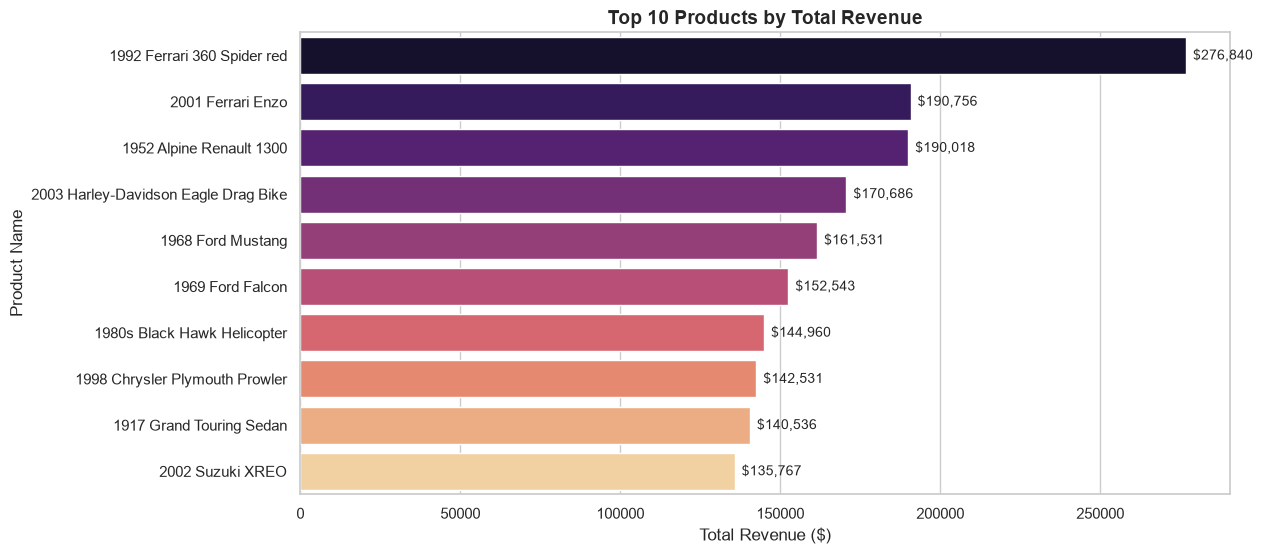

In [12]:
top_products = df.groupby('productName')['totalAmount'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='totalAmount', y='productName', data=top_products, palette='magma')
plt.title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Annotating exact revenue values on top of bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'${width:,.0f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.show()

### 5.2 Revenue share by product line
Categorizing revenue performance by primary product lines (e.g., Classic Cars, Vintage Cars, Motorcycles).

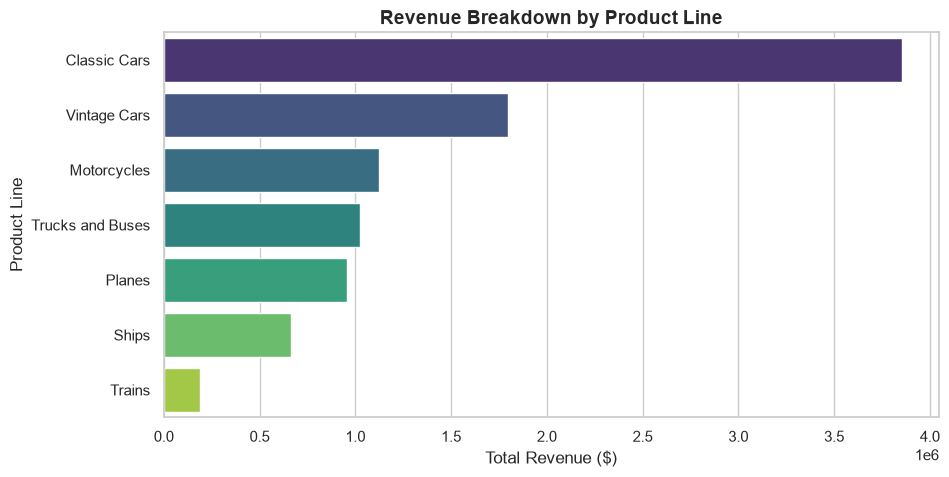

In [13]:
line_revenue = df.groupby('productLine')['totalAmount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='totalAmount', y='productLine', data=line_revenue, palette='viridis')
plt.title('Revenue Breakdown by Product Line', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Line', fontsize=12)
plt.show()

### 5.3 Monthly sales trend over time
Tracking sales volume patterns across historical monthly periods to identify growth dynamics and seasonality.

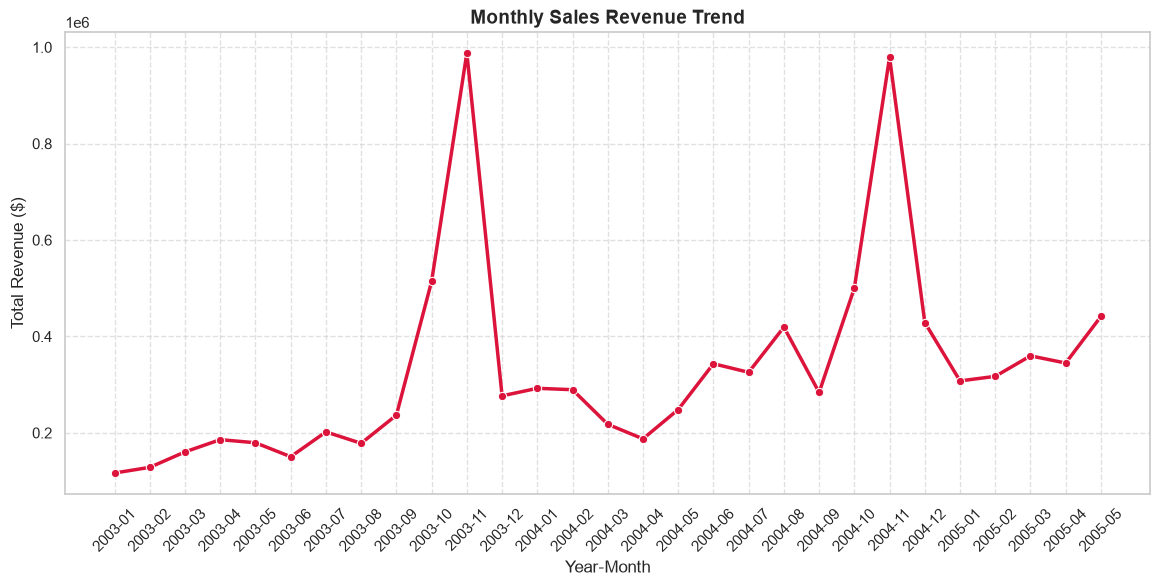

In [14]:
monthly_trend = df.groupby('year_month')['totalAmount'].sum().reset_index()
monthly_trend['year_month'] = monthly_trend['year_month'].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(x='year_month', y='totalAmount', data=monthly_trend, marker='o', color='crimson', linewidth=2.5)
plt.title('Monthly Sales Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5.4 Geographic market performance
Analyzing top revenue contributing countries to identify global market concentration.

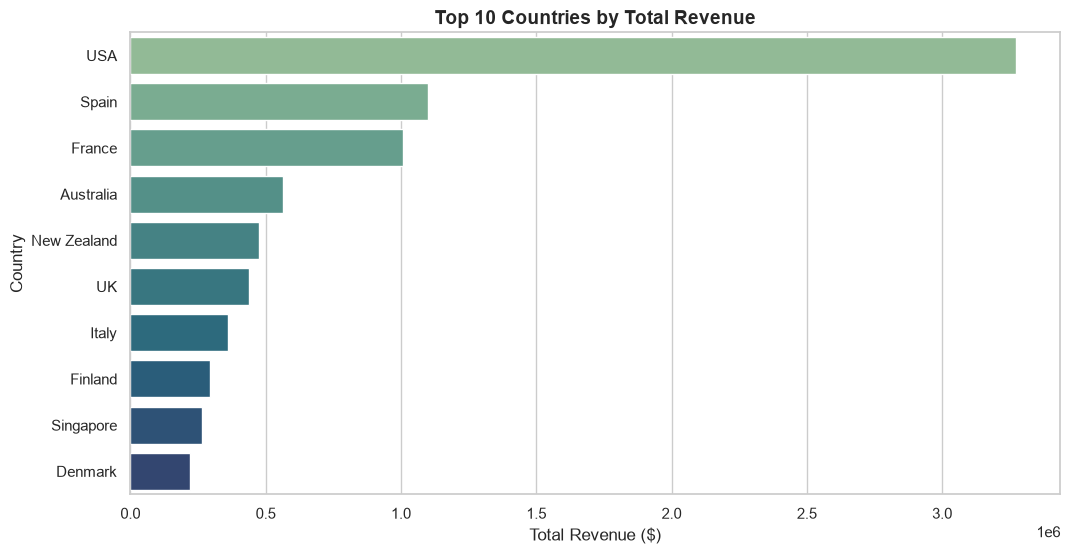

In [15]:
top_countries = df.groupby('country')['totalAmount'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='totalAmount', y='country', data=top_countries, palette='crest')
plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

## 6. Conclusion & key insights
Summary output of high level project metrics derived from the exploratory analysis.

In [ ]:
top_prod = top_products.iloc[0]['productName']
top_cat = line_revenue.iloc[0]['productLine']
top_cntry = top_countries.iloc[0]['country']
total_revenue = df['totalAmount'].sum()

print("     Classicmodels EDA project insights summary   ")
print(f"1. Total cleaned records analyzed: {df.shape[0]}")
print(f"2. Gross revenue analyzed: ${total_revenue:,.2f}")
print(f"3. Highest revenue product Line: {top_cat}")
print(f"4. Top single Product by Sales: {top_prod}")
print(f"5. Primary Market by Sales Volume: {top_cntry}")